## **Section 1: Project Introduction**

**Mall Customer Segmentation using K-Means**

This project applies K-Means clustering to segment mall customers into different groups based on their annual income and spending behavior. The goal is to identify distinct customer segments that businesses can target with different marketing strategies.

## **Section 2: Import Libraries**

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## **Section 3: Load Dataset**

In [4]:
df = pd.read_csv("C:\\Users\\A\\Downloads\\Mall_Customers.csv")

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## **Section 4: Data Exploration**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [17]:
#This is useful for categorical columns or small sets of discrete values.
#You’ll immediately spot things like '?', 'unknown', or 'N/A'.
for col in df.columns:
    print(f"--- {col} ---")
    print(df[col].unique()[:20])  # Show first 20 unique values

--- CustomerID ---
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
--- Gender ---
['Male' 'Female']
--- Age ---
[19 21 20 23 31 22 35 64 30 67 58 24 37 52 25 46 54 29 45 40]
--- Annual Income (k$) ---
[15 16 17 18 19 20 21 23 24 25 28 29 30 33 34 37 38 39 40 42]
--- Spending Score (1-100) ---
[39 81  6 77 40 76 94  3 72 14 99 15 13 79 35 66 29 98 73  5]


## **Section 5: Data Visualization**

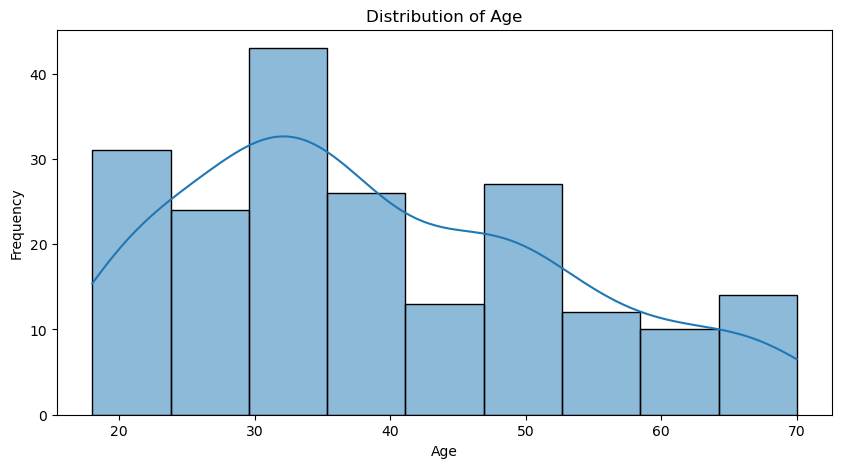

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

This distribution is skewed to the right, meaning a decent number of the customers are 50 and above. While most of the customers are aged between 20 and 40

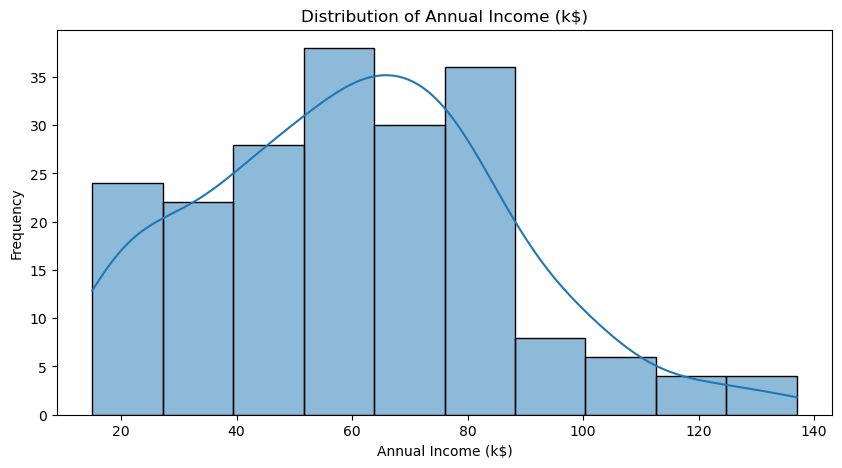

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Annual Income (k$)', kde=True)
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

This distribution is skewed to the right meaning most values are on the lower end while a few of the customers earn higher incomes

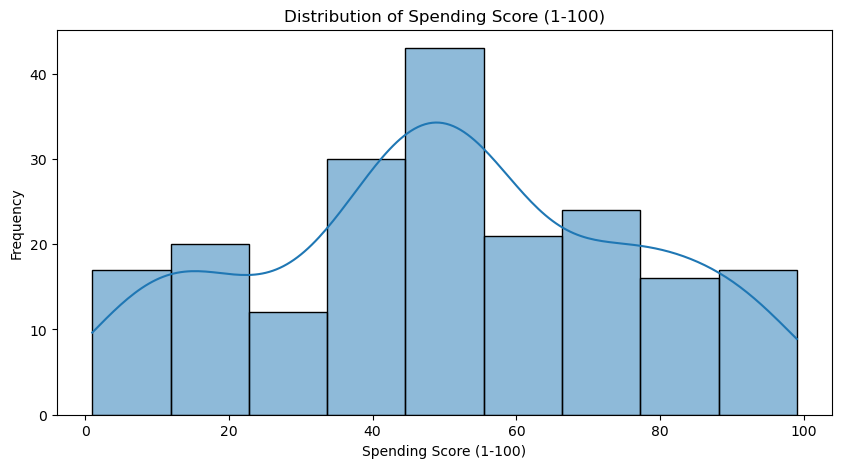

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Spending Score (1-100)', kde=True)
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

This is distribution is roughly normal with higher values concentrated in the middle

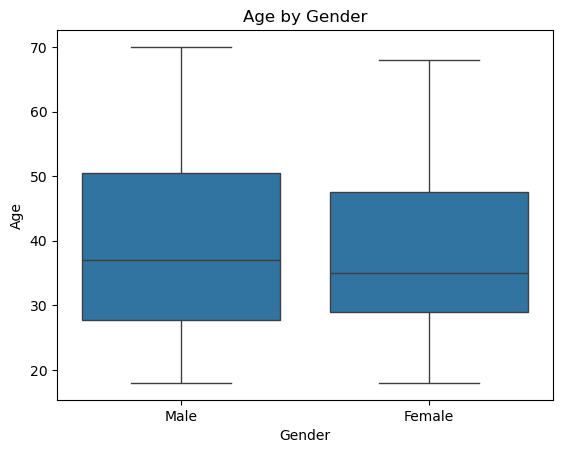

In [25]:
plt.figure()
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age by Gender')
plt.show()

Both gender groups show right skewed age distributions, with the median closer to the lower quartile. Male customers have a slightly higher median age, suggesting they are marginally older on average

In [27]:
Average_Spending_Score_by_gender = df.groupby('Gender')['Spending Score (1-100)'].mean() #This returns the average spending score by gender
Average_Spending_Score_by_gender 

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

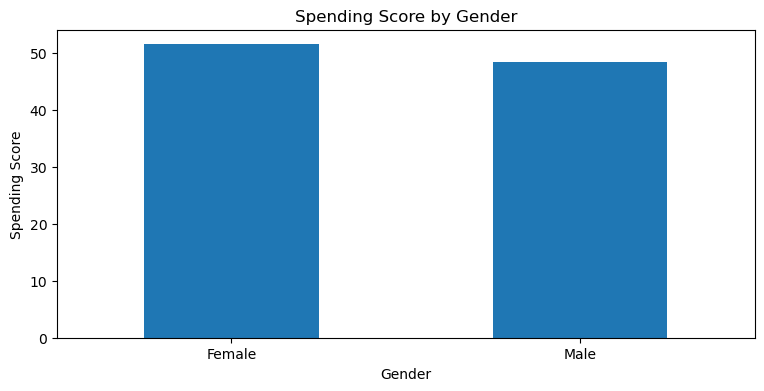

In [31]:
plt.figure(figsize=(9,4))
Average_Spending_Score_by_gender.plot(kind='bar')
plt.xticks(rotation=0)
plt.xlabel('Gender')
plt.ylabel('Spending Score')
plt.title('Spending Score by Gender')
plt.show()

This shows there is a slight difference in the spending score of both genders with the female spending higher than the male

In [86]:
Average_Annual_Income_by_gender = df.groupby('Gender')['Annual Income (k$)'].mean() #This returns the average spending score by gender
Average_Annual_Income_by_gender  

Gender
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64

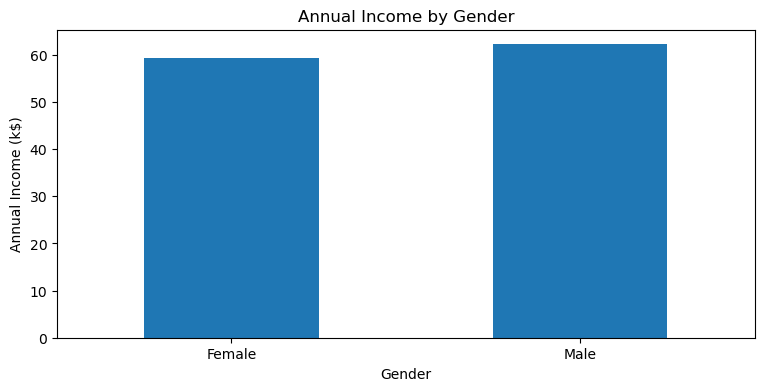

In [88]:
plt.figure(figsize=(9,4))
Average_Annual_Income_by_gender.plot(kind='bar')
plt.xticks(rotation=0)
plt.xlabel('Gender')
plt.ylabel('Annual Income (k$)')
plt.title('Annual Income by Gender')
plt.show()

This shows there is a slight difference in the annual income of both genders with the male earning higher than the female.
Depite the Male customers earning higher income, the female customers spends higher than the Male Customers.

## **Section 6: Determine Optimal Clusters**

In [31]:
clustering_features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
clustering_features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


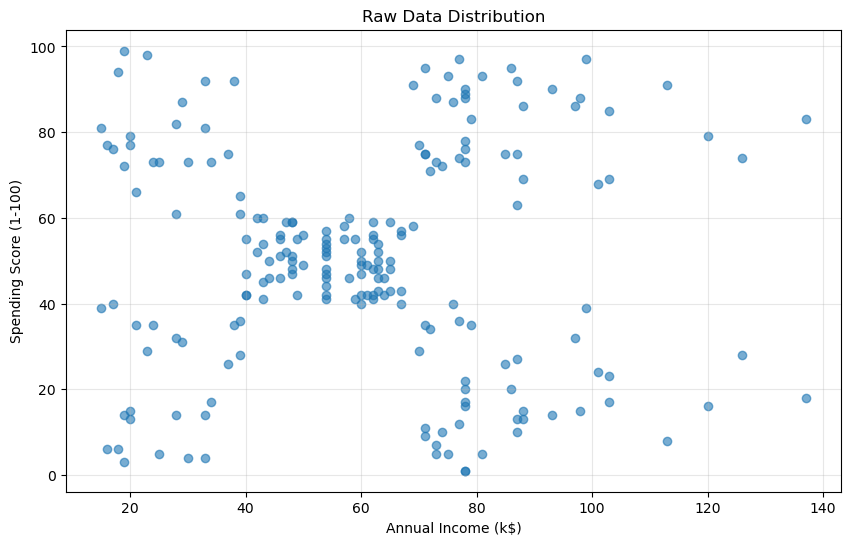

In [33]:
# Visualize the raw data
plt.figure(figsize=(10, 6))
plt.scatter(clustering_features['Annual Income (k$)'], clustering_features['Spending Score (1-100)'], alpha=0.6)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Raw Data Distribution')
plt.grid(True, alpha=0.3) # alpha=0.3 makes the grid lines faint (semi-transparent).
plt.show()

In [35]:
# Test different numbers of clusters
k_range = range(2, 11)
empty_inertias = []

for k in k_range:
    # Create KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit the model
    kmeans.fit(clustering_features)

    # Store the inertia (within-cluster sum of squares)
    empty_inertias.append(kmeans.inertia_)

    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

k=2: Inertia = 181363.60
k=3: Inertia = 106348.37
k=4: Inertia = 73679.79
k=5: Inertia = 44448.46
k=6: Inertia = 37233.81
k=7: Inertia = 30241.34
k=8: Inertia = 25036.42
k=9: Inertia = 21916.79
k=10: Inertia = 20072.07


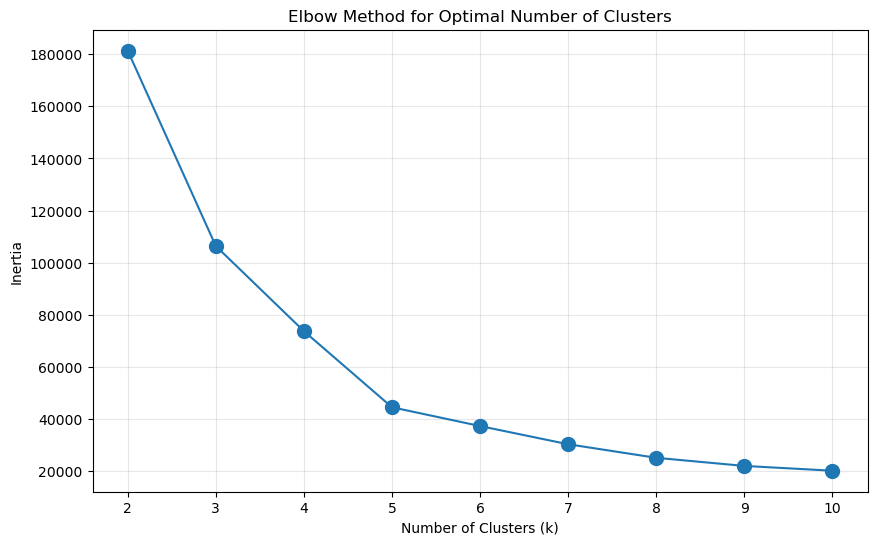

In [37]:
# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, empty_inertias, 'o-', markersize=10)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
silhouette_scores = []

for k in k_range:
    # Create and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(clustering_features)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(clustering_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

k=2: Silhouette Score = 0.297
k=3: Silhouette Score = 0.468
k=4: Silhouette Score = 0.493
k=5: Silhouette Score = 0.554
k=6: Silhouette Score = 0.540
k=7: Silhouette Score = 0.529
k=8: Silhouette Score = 0.455
k=9: Silhouette Score = 0.456
k=10: Silhouette Score = 0.441


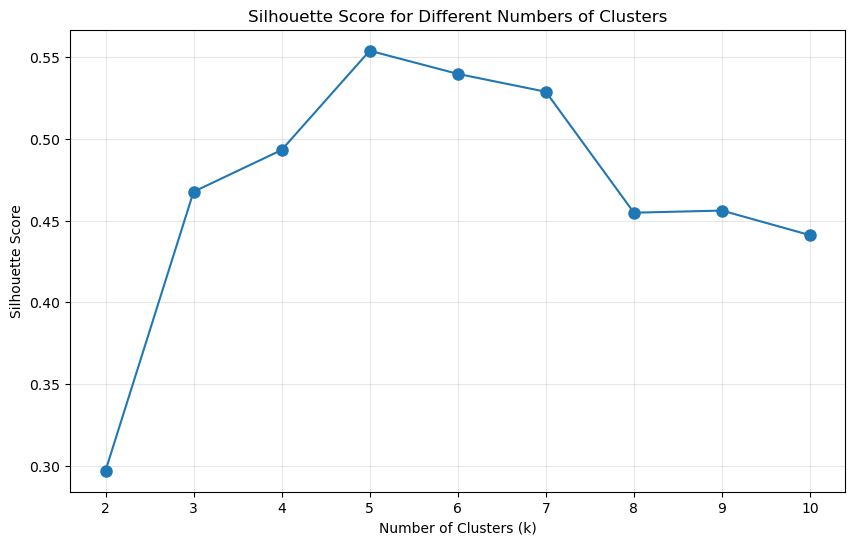

In [41]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'o-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

## **Section 7: Apply K-means**

In [43]:
# Create the final model
final_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit the model and get cluster labels
cluster_labels = final_kmeans.fit_predict(clustering_features)

In [45]:
# Add cluster labels to original dataframe
df_clustered = df.copy()
df_clustered['predicted_cluster'] = cluster_labels

In [47]:
df_clustered["predicted_cluster"].unique()

array([4, 2, 0, 1, 3])

In [63]:
df_clustered.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),predicted_cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## **Section 8: Visualize Clusters**

In [51]:
# Cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts()
print(cluster_counts)

0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


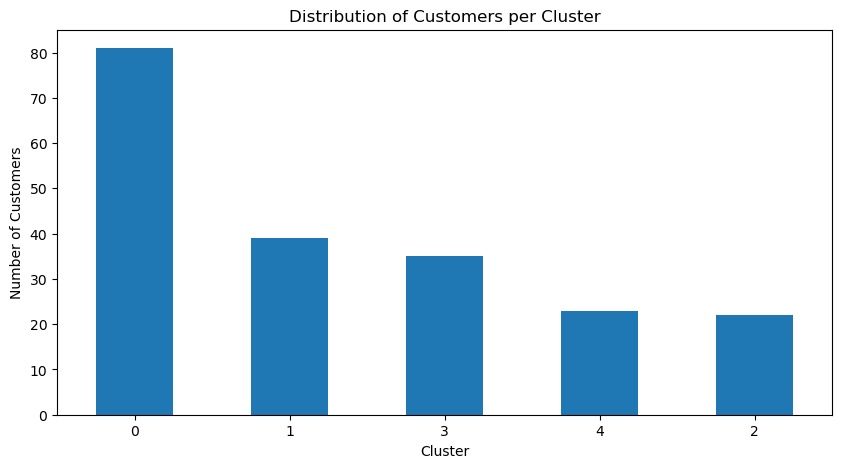

In [65]:
plt.figure(figsize=(10, 5))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers per Cluster')
plt.xticks(rotation=0)
plt.show()

## **Section 9: Interpret Clusters**

**Cluster Interpretation:**
The clustering algorithm grouped customers based on income and spending behavior. Some clusters represent high-income high-spending customers, while others represent low-income low-spending groups. These insights can help businesses tailor marketing strategies to different customer segments.

In [71]:
cluster_characteristics = df_clustered.groupby('predicted_cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
display(cluster_characteristics)

,Annual Income (k$),Spending Score (1-100)
predicted_cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Cluster 0: Moderate Income and Moderate Spending Score
Cluster 1: High Income and High Spending Score
Cluster 2: Low Income and High Spending Score
Cluster 3: High Income and Low Spending Score
Cluster 4: Low Income and Low Spending Score

**Observation:** Cluster 2 consist of great customers, the focus should be on how to retain them. 
Cluster 3 consist of customers with high income and low spending score, it might be that their preferable product aren't in the mall. They have money to spend, the focus should be on finding out why they aren't spending more in the mall.

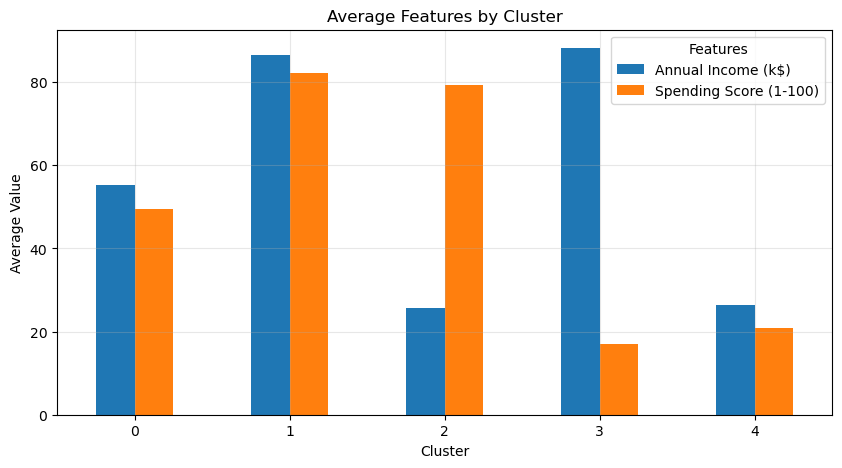

In [73]:
# Plot 4: Feature comparison by cluster
fig, axes = plt.subplots(figsize=(10, 5))
cluster_characteristics.plot(kind='bar', ax=axes)
axes.set_xlabel('Cluster')
axes.set_ylabel('Average Value')
axes.set_title('Average Features by Cluster')
axes.tick_params(axis='x', rotation=0)
axes.legend(title='Features')
axes.grid(True, alpha=0.3)
plt.show()